### Description
This notebook runs dcfe two basins. Deliberately keeping things small, so as to enable testing and debugging.

In [1]:
from neuralhydrology.utils.config import Config
from neuralhydrology.utils.DCFE_utils import get_dcfe_params
from neuralhydrology.datautils import utils
from pathlib import Path
import torch
from neuralhydrology.nh_run import start_run


In [2]:
# Grab config file so we can see if the code works
#config_path = Path('/Users/danielmckenzie/Documents/Active_Research/Ziyu/neuralhydrology/neuralhydrology/examples/07-DifferentialCFE-Model/2basinTest_devMultiBasin.yml')
config_path = Path('/Users/ziyu/Library/CloudStorage/OneDrive-ColoradoSchoolofMines/Documents/College/ResearchStuff/NextGen/neuralhydrology/examples/07-DifferentialCFE-Model/2basinTest_devMultiBasin.yml')
config = Config(config_path, dev_mode=True)
basins = utils.load_basin_file(getattr(config, "train_basin_file"))

testDF = get_dcfe_params(config)
testDF.loc['02177000']
#testDF.loc['02349900']

depth                                                        tensor(2.)
bb                                                       tensor(1.8747)
satdk                                                    tensor(0.0007)
satpsi                                                   tensor(0.1889)
slop                                                     tensor(0.8340)
smcmax                                                   tensor(0.2987)
wltsmc                                                   tensor(0.0521)
D                                                            tensor(2.)
mult                                                         tensor(1.)
catchment_area_km2                                     tensor(111.1100)
refkdt                                                   tensor(0.8883)
max_gw_storage                                           tensor(0.2016)
expon                                                    tensor(1.8009)
Cgw                                                      tensor(

In [3]:
# by default we assume that you have at least one CUDA-capable NVIDIA GPU
if torch.cuda.is_available():
    print("GPU")
    start_run(config_file=Path("2basinTest_devMultiBasin.yml"))

# fall back to CPU-onl y mode
else:
    print("CPU")
    start_run(config_file=Path("2basinTest_devMultiBasin.yml"), gpu=-1)

CPU
2025-08-08 19:07:40,084: Logging to /Users/ziyu/Library/CloudStorage/OneDrive-ColoradoSchoolofMines/Documents/College/ResearchStuff/NextGen/neuralhydrology/examples/07-DifferentialCFE-Model/runs/DevMultiBasin_Test_0808_190740/output.log initialized.
2025-08-08 19:07:40,084: ### Folder structure created at /Users/ziyu/Library/CloudStorage/OneDrive-ColoradoSchoolofMines/Documents/College/ResearchStuff/NextGen/neuralhydrology/examples/07-DifferentialCFE-Model/runs/DevMultiBasin_Test_0808_190740
2025-08-08 19:07:40,086: ### Run configurations for DevMultiBasin_Test
2025-08-08 19:07:40,086: experiment_name: DevMultiBasin_Test
2025-08-08 19:07:40,087: train_basin_file: 2_basin.txt
2025-08-08 19:07:40,088: validation_basin_file: 2_basin.txt
2025-08-08 19:07:40,088: test_basin_file: 2_basin.txt
2025-08-08 19:07:40,089: train_start_date: 2000-10-01 00:00:00
2025-08-08 19:07:40,089: train_end_date: 2014-09-30 00:00:00
2025-08-08 19:07:40,090: validation_start_date: 1990-10-01 00:00:00
2025-0

2025-08-08 19:22:25,771: Using the model weights from runs/DevMultiBasin_Test_0808_190740/model_epoch003.pt
Metrics for 1D are calculated over last 1 elements only. Ignoring 364 predictions per sequence.
# Evaluation: 100%|██████████| 2/2 [00:00<00:00,  2.73it/s]
2025-08-08 19:22:26,514: Stored metrics at runs/DevMultiBasin_Test_0808_190740/test/model_epoch003/test_metrics.csv
2025-08-08 19:22:26,515: Stored results at runs/DevMultiBasin_Test_0808_190740/test/model_epoch003/test_results.p


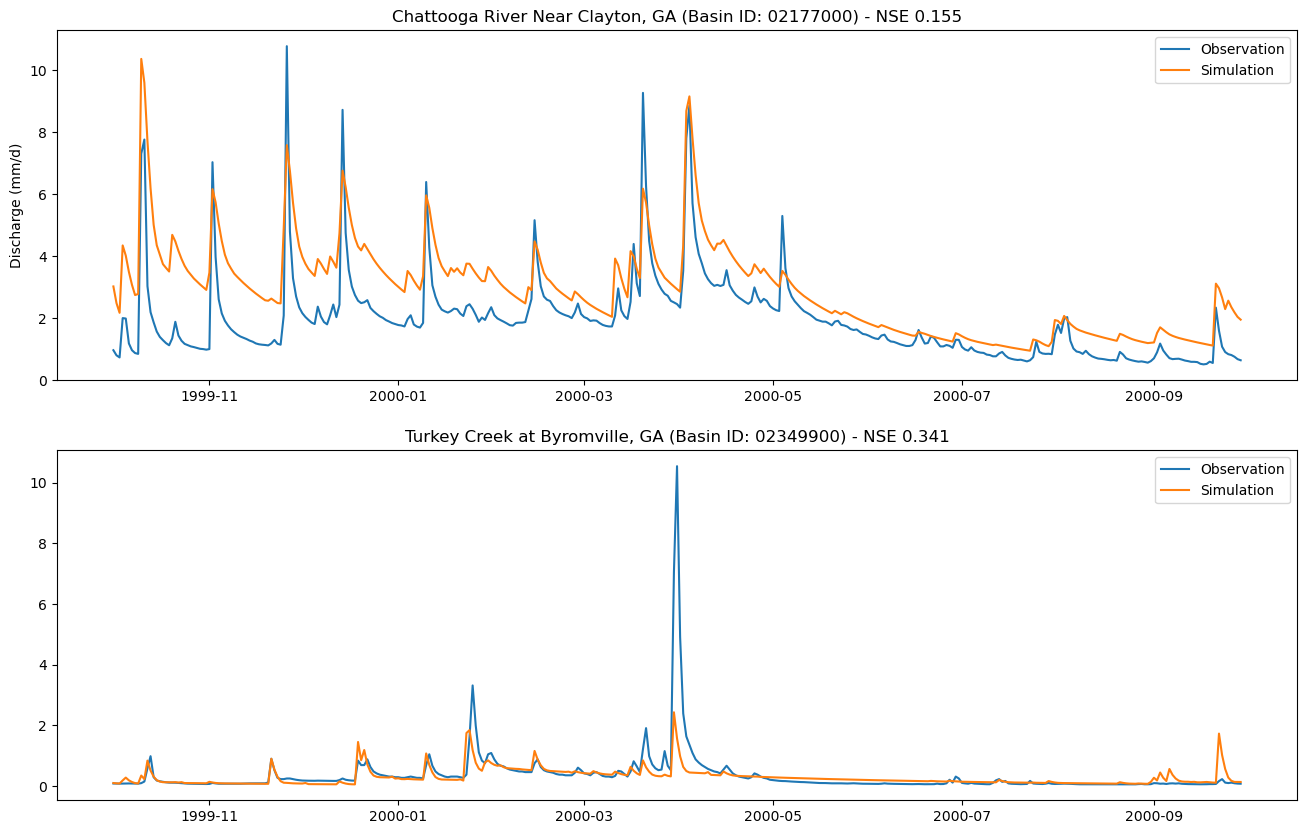

In [4]:
from neuralhydrology.evaluation import metrics, get_tester
import pandas as pd
from neuralhydrology.utils.config import Config
import matplotlib.pyplot as plt

run_dir = Path("runs/DevMultiBasin_Test_0808_190740")
run_config = Config(run_dir / "config.yml")

# create a tester instance and start evaluation
tester = get_tester(cfg=Config(run_dir / "config.yml"), run_dir=run_dir, period="test", init_model=True)
results = tester.evaluate(save_results=True, metrics=run_config.metrics)

results.keys()


# Extract a date slice of observations and simulations
Result_xr_1 = results['02177000']['1D']['xr'].sel(date=slice("10-1999", None))

# Get the scalar date and the 1D array of time_step values
date_scalar_1 = Result_xr_1.coords['date'][0].values  # Extract as a NumPy scalar
time_step_values_1 = Result_xr_1.coords['time_step'].values  # Extract as NumPy array
# Broadcast the scalar date across time_step and add the timedelta
datetime_values_1 = date_scalar_1 + pd.to_timedelta(time_step_values_1, unit='D')

# Add the datetime as a new coordinate to Result_xr
Result_xr_1 = Result_xr_1.assign_coords(datetime=("time_step", datetime_values_1))

fig, ax = plt.subplots(2, 1, figsize=(16,10))

# Extract observations and simulations
qobs_1 = Result_xr_1['QObs(mm/d)_obs']
qsim_1 = Result_xr_1['QObs(mm/d)_sim']

result_NSE_1 = metrics.nse(qobs_1[0,:], qsim_1[0,:])
# Plot observations and simulations
ax[0].plot(Result_xr_1['datetime'], qobs_1[0,:], label="Observation")
ax[0].plot(Result_xr_1['datetime'], qsim_1[0,:], label="Simulation")
ax[0].set_ylabel("Discharge (mm/d)")
ax[0].set_title(f"Chattooga River Near Clayton, GA (Basin ID: 02177000) - NSE {result_NSE_1:.3f}")
_ = ax[0].legend()

# the other basin
# Extract a date slice of observations and simulations
Result_xr_2 = results['02349900']['1D']['xr'].sel(date=slice("10-1999", None))

# Get the scalar date and the 1D array of time_step values
date_scalar_2 = Result_xr_2.coords['date'][0].values  # Extract as a NumPy scalar
time_step_values_2 = Result_xr_2.coords['time_step'].values  # Extract as NumPy array

# Broadcast the scalar date across time_step and add the timedelta
datetime_values_2 = date_scalar_2 + pd.to_timedelta(time_step_values_2, unit='D')

# Add the datetime as a new coordinate to Result_xr
Result_xr_2 = Result_xr_2.assign_coords(datetime=("time_step", datetime_values_2))

# Extract observations and simulations
qobs_2 = Result_xr_2['QObs(mm/d)_obs']
qsim_2 = Result_xr_2['QObs(mm/d)_sim']

result_NSE_2 = metrics.nse(qobs_2[0,:], qsim_2[0,:])
# Plot observations and simulations
ax[1].plot(Result_xr_2['datetime'], qobs_2[0,:], label="Observation")
ax[1].plot(Result_xr_2['datetime'], qsim_2[0,:], label="Simulation")
ax[0].set_ylabel("Discharge (mm/d)")
ax[1].set_title(f"Turkey Creek at Byromville, GA (Basin ID: 02349900) - NSE {result_NSE_2:.3f}")
_ = ax[1].legend()
